# Module Showcase

## Preparing Mapmeta

Assuming maps already exist from mapmaking, we setup a config file based on the settings used in mapmaking.

In [1]:
with open('configs/local.yaml', 'r') as f:
    config = f.readlines()

print(*config)

map_data_dir: "/global/homes/a/andrs/data/beams/lat/pointing_model_bs_relcal/"
 
 # Must be the same context as the used mapmaking conf context
 context: "/global/homes/a/andrs/BeamChar/Work/make_maps/preproc/use_this_local.yaml"
 
 # Path to save the referential h5 file with map metadata and fit info
 map_ref: "/global/homes/a/andrs/BeamChar/Work/analyze_maps/"
 
 
 # Label your epochs to make reference easier!
 epochs:
     - ['ep1', 1744848000, 1745150000]
     - ['ep2', 1745150000, 1749355200]
     - ['ep3', 1749600000, 1755576000]
     - ['ep4', 1756699200, 20000000000]


Map metadata and fit information will be stored in `.h5` files. We can create metadata for the existing maps by running the `setup_mapmeta.py` file:

In [14]:
import sys

cmd = [
    sys.executable,
    "setup_mapmeta.py",
    "configs/local.yaml"
]

os.system(" ".join(cmd));

Warning! obs_1756136224_lati1_111 is not within defined epochs! (1756136224.9927125)
Warning! obs_1756136224_lati1_111 is not within defined epochs! (1756136224.9927125)
Warning! obs_1756136224_lati1_111 is not within defined epochs! (1756136224.9927125)
Warning! obs_1756136224_lati1_111 is not within defined epochs! (1756136224.9927125)
Warning! obs_1756136224_lati1_111 is not within defined epochs! (1756136224.9927125)
Warning! obs_1756136224_lati1_111 is not within defined epochs! (1756136224.9927125)
Warning! obs_1756154142_lati1_111 is not within defined epochs! (1756154144.8627124)
Warning! obs_1756154142_lati1_111 is not within defined epochs! (1756154144.8627124)
Warning! obs_1756154142_lati1_111 is not within defined epochs! (1756154144.8627124)
Warning! obs_1756136201_lati6_111 is not within defined epochs! (1756136224.0977125)
Warning! obs_1756136201_lati6_111 is not within defined epochs! (1756136224.0977125)
Warning! obs_1756154117_lati6_111 is not within defined epochs! (

0

Note that some warnings have been issued. Warnings will not outright cancel the inclusions of the observations, where as errors will.

Now you should have a `mapmeta.h5` wherever your config file specified it to be. Assuming it is in the same directory as this notebook, we will see an example of a map entry.
We will do so by using functions tied to the `map_fun.py` file, which will be imported as `mf`. We will also import the `models.py` file as `models`.

In [2]:
import numpy as np
import os

from scipy.ndimage import fourier_shift
from scipy.ndimage import distance_transform_edt
from tqdm.notebook import tqdm
import traceback

import map_fun as mf
import models

mapmeta = mf.load_h5("mapmeta.h5")
print(f"Meta Name: {list(mapmeta.keys())[0]}")
mapmeta[list(mapmeta.keys())[0]]

Meta Name: obs_1744857536_lati1_111_f090_ufm_mv21


{'band': 'f090',
 'ctime': np.float64(1744857537.7701917),
 'date': '2025-04-17 02:38:57',
 'epoch': 'ep1',
 'obs_id': '1744857536',
 'obstime_reg': 'night',
 'path_pattern': '/global/homes/a/andrs/data/beams/lat/pointing_model_bs_relcal/mars/17448/obs_1744857536_lati1_111/obs_1744857536_lati1_111_ufm_mv21_f090',
 'source': 'mars',
 'sunrise': '2025-04-17 10:45:27',
 'sunset': '2025-04-17 22:15:29',
 'tube_slot': 'lati1',
 'valid_data': np.True_,
 'wafer': 'ufm_mv21',
 'wafers_present': '111'}

As we can see a bunch of useful information is stored in each entry. The key to each entry is a meta name that combines different relevant tags.

## Working with maps

In order to facilitate working with different maps, we will use the custom class `obsmap` from `mf`. We will explore a way to filter the maps we want to use later but for now we can simply load maps by passing each entry in the mapmeta file to the class and create a new instance from it.

In [2]:
maps = [mf.obsmap(meta) for key, meta in mapmeta.items()]
map2use = maps[0]
print(map2use.meta_name, map2use.obs_id, map2use.band, map2use.wafer, map2use.epoch, map2use.tube_slot, sep='\n')

obs_1744857536_lati1_111_f090_ufm_mv21
1744857536
f090
ufm_mv21
ep1
lati1


We can load data for each map by calling the attributes `solved`, `weights` or `binned` (each is tied to their corresponding file from mapmaking). By default data is never loaded until called for the first time. When the data is called, it creates a copy of it. Keep in mind these attributes are considered read-only.

**NOTE**: If data is faulty for a map (or missing), it will raise and Exception when loading data. While the `fit_primary_signal` function is equipped to deal with this already, other functions are not.

### Map querys

We can query specific maps after or before they are created by using the `query_maps` function. What is does is return the meta_names of maps that satisfy the requested criteria from the mapmeta file. We can then pass these meta names to obsmap to create new instances or simply keep the existing instances for which the meta names exist within the retrieved list.

In [6]:
query = mf.query_maps(mapmeta, 
    tube_slot="lati1",
    wafer="ufm_mv21",
    band="f090",
    epoch='ep4')

selection = [map2use for map2use in maps if map2use.meta_name in query]
len(selection)

9

### Adding new metadata

Suppose now we want to add new metadata fields. Lets create a new one that will specify which entries have invalid data. We do so by using:

In [9]:
# First you must add the field for ALL maps
# Also avoid storing dicts or arrays as they are not metadata!
for key, meta in mapmeta.items():
    mapmeta[key]['valid_data'] = True

mapmeta[maps[0].meta_name]['valid_data'] = False

mf.save_h5("mapmeta.h5", mapmeta);

# No need to load mapmeta again

#### Quick Data Check

You can quickly check valid data by running the following code once from scrath and then restarting the kernel to free memory.

In [4]:
# RUN ONCE
import map_fun as mf

mapmeta = mf.load_h5("mapmeta.h5")
maps = [mf.obsmap(meta) for key, meta in mapmeta.items()]

for key, meta in mapmeta.items():
    mapmeta[key]['valid_data'] = True

for map2use in maps:
    try:
        var = map2use.solved[0]
    except:
        mapmeta[map2use.meta_name]['valid_data'] = False

mf.save_h5("mapmeta.h5", mapmeta);

In [1]:
### After kernel restart

import map_fun as mf
import matplotlib.pyplot as plt
import numpy as np
import models

mapmeta = mf.load_h5("mapmeta.h5")
maps = [mf.obsmap(meta) for key, meta in mapmeta.items() if meta['valid_data']]

## Fitting Primary Signal

We assume maps have a primary signal and a secondary / residual signal. We can fit the primary signal using a predefined model. Models are classes that inherit from the `BaseModel` class in the `models` package. A model class has specific methods that need to be defined in order to work with the fitter, which uses `scipy.optimize.curve_fit`.

We will take a look at how to fit maps with an `EllipticGaussian` model.

In [2]:
model = models.EllipticGaussian
results = mf.fit_maps(maps, model = models.EllipticGaussian, sigma_method = mf.weights_sigma_method, comp = 'T')

Fitting maps w/ EllipticGaussian model:   0%|          | 0/350 [00:00<?, ?it/s]

350 maps have been fitted out of 350 total maps.


Note how we used a `sigma_method` in the fitter. There is also an option for a `mask_method`. Those options allow a function to be passed to the fitter that will dynamically generate the errors and or masked pixels to be used in the fitting process. Check the `map_fun.py` file for details on how these work.

The fits are returned as a series of arrays containing specific information. We will save these fits as an `h5` file. Note that the saved fits will have no inherit information about what model generated them unless manually added. The name of the saved fit file should be chosen carefully then to avoid confution.

In [3]:
savename = "fits/EllipticGaussian.h5"
mf.save_map_fits(savename, maps, results)

## Loading Primary Fits

We can load any number of fits by loading the corresponding `h5` file and passing it as a dictionary to each map through `obsmap.load_fit` alongside the model used to create said fits. The way this works is that `load_fit` uses the methods defined for the passed model class to work out what each datapoint represents. The relevant fit information is stored under an instance of the model class, while that instance is stored as an attribute to the obsmap instance.

In [4]:
fitmeta = mf.load_h5("fits/EllipticGaussian.h5")
[map2use.load_fit(models.EllipticGaussian, fitmeta) for map2use in maps];

map2use = maps[0]
# Prints out tuple of value and error
map2use.EllipticGaussian.ellip

(0.0037521991242852135, 0.00030403907392169)

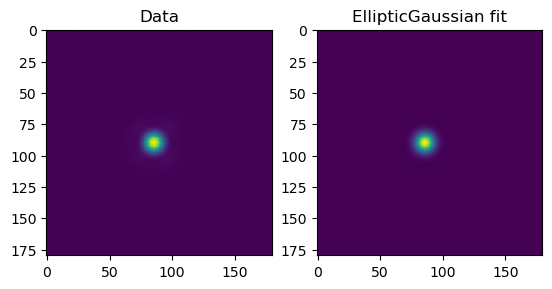

In [5]:
T = map2use.solved[0]
popt = map2use.EllipticGaussian.get_popt()
ny,nx = T.shape
y, x = np.mgrid[0:ny, 0:nx]
coords = (y, x)
fitdata = models.EllipticGaussian().func(coords, *popt).reshape((ny,nx))

plt.subplot(121)
plt.title('Data')
plt.imshow(map2use.solved[0])
plt.subplot(122)
plt.title('EllipticGaussian fit')
plt.imshow(fitdata)
plt.show()

## Map Co-Adds

We have the option to co-add maps to increase SNR, get a best-fit model for a wafer-freq combination, inspect predominant features, etc. We first need to select the maps we wish to use, then normalize and center them. We can do this by using `norm_center_map` over each map we wish to coadd. Once our maps are ready to coadd, we use `coadd_maps` to do so, with the option to weigh the map averaging with some set of weights (or exclude that option and simply take the mean).

**NOTE**: Currently coadd makes no attempt to return the error or weights of the coadded maps, since so far the systematic error dominates over random / stochastic error.

**NOTE**: Behaviour of a lot of functions when using different sized maps is yet to be tested thorougly.

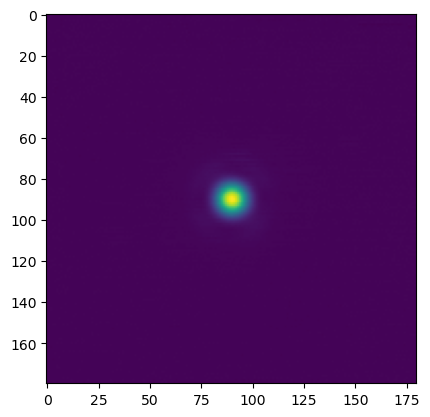

In [6]:
query = mf.query_maps(mapmeta,
    tube_slot="lati1",
    wafer="ufm_mv21",
    band="f090",
    epoch='ep4')

selection = [x for x in maps if x.meta_name in query]

tocoadd = [mf.norm_center_map(x.solved[0], amp=x.EllipticGaussian.amp[0], offset=x.EllipticGaussian.offset[0], 
                center=(x.EllipticGaussian.muy[0], x.EllipticGaussian.mux[0])) for x in selection]

coadd = mf.coadd_maps(tocoadd, weights=[x.weights[0][0] for x in selection])

plt.imshow(coadd)
plt.show()

## Fitting coadds

We can fit coadds by using the `fit_signals` function with some slight adjustments. That function expects the `signals` argument to be a list of arrays, so even when fitting a single signal or coadd it must be passed inside of a list. The results will also be a list. This function also allows `sigma_method` and `mask_method` kwargs, though a signal is passed onto these functions rather than an obsmap instance so previous function methods used for map fits might not work unless adapted.

In [105]:
import importlib
importlib.reload(mf)

<module 'map_fun' from '/global/u2/a/andrs/BeamChar/Work/analyze_maps/map_fun.py'>

In [7]:
model = models.EllipticGaussian
results = mf.fit_signals([coadd], model = models.EllipticGaussian)

Fitting maps w/ EllipticGaussian model:   0%|          | 0/1 [00:00<?, ?it/s]

1 signals have been fitted out of 1 total maps.


We will save coadd fits (or direct signal fits) in an h5 file. We can create as many h5 files as we want but ideally we will store all coadd fits in a single file. We can do so by using the `save_signal_fits` function and using the `keys` kwarg to define the name(s) of the fit(s).

**Note**: This function expects both results and keys to be lists, so make sure to pass individual values within list brackets ([]).

In [8]:
mf.save_signal_fits("fits/coadd_fits.h5", results, keys=['EllipticGaussian-democoadd'])

coadd_fits = mf.load_h5("fits/coadd_fits.h5")

#### Adding more fits to the coadd file

You can add another fit to an h5 file of this kind by doing the following:

In [12]:
# 0. Have fit to add in the form of results (what mf.fit_signals returns)
results_ = results.copy()

# 1. Load file
coadd_fits = mf.load_h5("fits/coadd_fits.h5")

# 2. Format new entry as follows
new_entry = mf.format_results(results_, "DummyFitExample")

# 3. Append new entry to dictionary
coadd_fits.update(new_entry)

# 4. Save directly as h5
mf.save_h5("fits/coadd_fits.h5", coadd_fits)

# 5. Reload and check
coadd_fits = mf.load_h5("fits/coadd_fits.h5")

coadd_fits.keys()

dict_keys(['DummyFitExample', 'EllipticGaussian-democoadd'])

## Fitting Residuals with Zernike

Lets use our previous coadd to obtain residuals first.

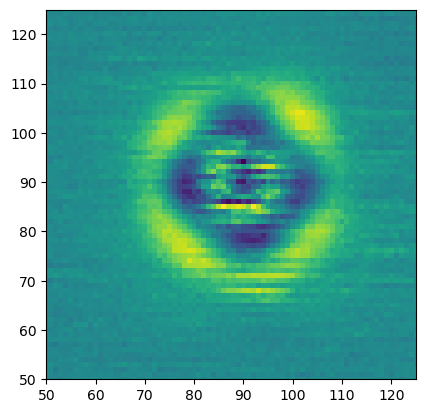

In [14]:
coadd_fits = mf.load_h5("fits/coadd_fits.h5")
T = coadd
popt = coadd_fits['EllipticGaussian-democoadd']["params"]
coords = mf.get_coords(T)
coadd_fit_recon = models.EllipticGaussian().func(coords, *popt).reshape((coords[0].shape))

residuals = T - coadd_fit_recon

plt.imshow(residuals)
plt.xlim(50, 125)
plt.ylim(50, 125)
plt.show()

We can clearly observe an outermost structure where beyond it lies a region of pure noise. We will fit this map using Zernike Decomposition over a fixed region.

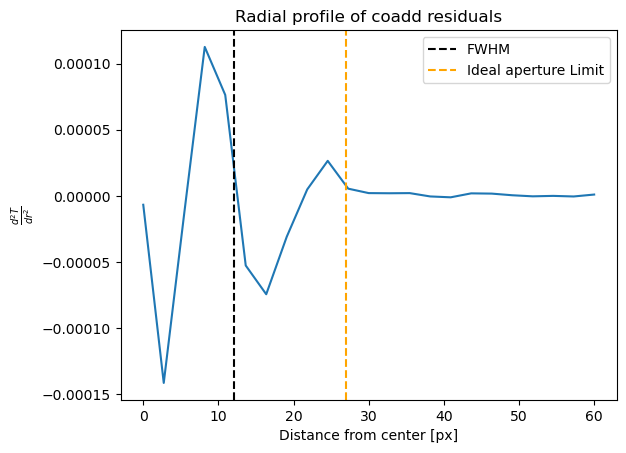

In [44]:
rmax = 60
X,Y = mf.radial_profile(residuals, center=(90,90), nbins=int(rmax//2.4), rmax=rmax)
plt.plot(np.linspace(0, rmax, len(np.diff(Y, n=2))), np.diff(Y, n=2))
plt.axvline(popt[4], c='black', ls='--', label='FWHM')
plt.axvline(27, c='orange', ls='--', label='Ideal aperture Limit')
plt.title('Radial profile of coadd residuals')
plt.xlabel('Distance from center [px]')
plt.ylabel(r'$\frac{d^2T}{dr^2}$')
plt.legend()
plt.show()

A good way to determine the ideal aperture limit is to radially bin the temperature coadd residual map from its center and calculate its second derivative. The radius at which the graph begins to stay flattened near the zero marks where the data starts being consistant with noise. So far a good empiric formula seems to be:

$$
r_{\text{lim}} = \frac{\theta_{\text{FWHM}}}{0.446} [px]
$$

Another option is also to just use:

$$
r_{\text{lim}} = 1.02 \frac{\lambda}{D} \cdot \frac{206265}{60 \cdot 0.446} \space[arcmin]
$$

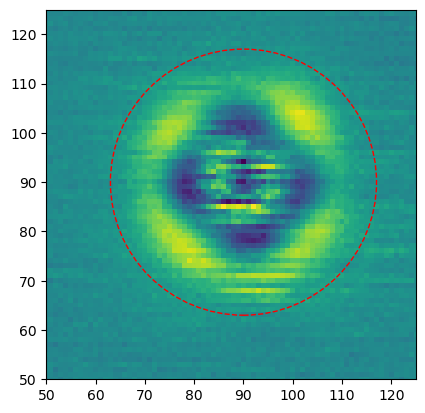

In [71]:
center = (90,90)
radius = 27

plt.imshow(residuals)
patch = plt.Circle(center, radius, ls='--', color='r', fill=False)
plt.gca().add_patch(patch)
plt.xlim(50, 125)
plt.ylim(50, 125)
plt.show()

Assuming we have selected our radius, we first create an array of all the zernike polynomials up to some $n_\text{max}$ scaled up to the specified radius. The idea is to create a single list before any for loop, as recaulating these modes for each map decomposition is quite taxing.

In [72]:
modes = mf.get_zernike_modes(nmax=30, mask_radius=27, coords=mf.get_coords(residuals), center=(90,90))

Next, we perform a least squares approximation of the coefficients and obtain them through the following functions:

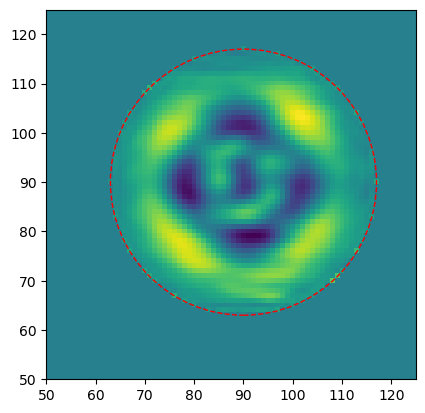

In [73]:
center = (90,90)
radius = 27

coeffs = mf.get_zernike_coeffs(residuals, center=(90,90), radius=27, zernike_modes=modes)

# Reconstruction can be obtained from simply doing
recon = np.sum(coeffs[:, None, None]*modes, axis=0)

plt.imshow(recon)
patch = plt.Circle(center, radius, ls='--', color='r', fill=False)
plt.gca().add_patch(patch)
plt.xlim(50, 125)
plt.ylim(50, 125)
plt.show()

Here we need to specify a bit of theory. Our normalization relies on the idea of supposing that the zernike modes are sufficiently orthogonal. While mathematically true, in a discrete representation some spillover is bound to happen, leading to cross correlation between modes. Calculating the full covariance matrix is extremely expensive so we can instead use an approximation that will work well for signals with strong zernike components. For such a method, we can obtain an estimate the variance of each coefficient with the following line:

In [74]:
coeffs, coeffs_var = mf.get_zernike_coeffs(residuals, center=(90,90), radius=27, zernike_modes=modes, get_var=True)

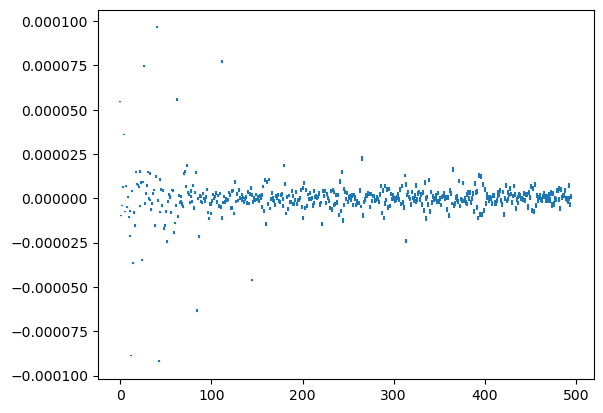

In [75]:
plt.errorbar(np.arange(len(coeffs)), coeffs, fmt='o', yerr=np.sqrt(coeffs_var), markersize=.1)
plt.show()

As we can see the error bars of significant modes are too small to be meaningful.

## Decreasing zernike modes

A lot of zernike modes model noise rather than significant structures. We can then eliminate useless modes by selecting modes outside of the standard deviation of coefficient values (or some multiple). We can also exclude possible random error by selecting a list of relevant mode orders and then checking if said selection accurately represents the points outside of the threshold limits. Note that the thresholds are always determined by the total contribution of each $(n,m)$ and $(n,-m)$ pair.

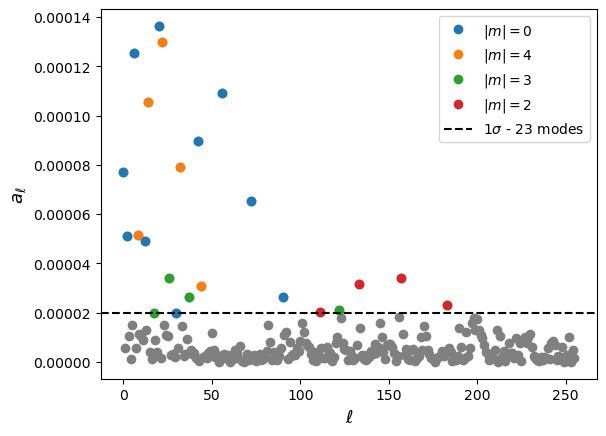

In [78]:
cf = mf.get_abs_coeffs(coeffs)

mzeros = mf.filter_zernike_modes(coeffs, angular_orders=[0], abs_indexes=True, ignore_thresh=False)
m4s = mf.filter_zernike_modes(coeffs, angular_orders=[4], abs_indexes=True, ignore_thresh=False)
m3s = mf.filter_zernike_modes(coeffs, angular_orders=[3], abs_indexes=True, ignore_thresh=False)
m2s = mf.filter_zernike_modes(coeffs, angular_orders=[2], abs_indexes=True, ignore_thresh=False)

plt.plot(np.arange(len(cf)), cf, 'o', color='gray', rasterized=True)
plt.plot(mzeros, cf[mzeros], 'o', label=r'$|m|=0$', rasterized=True)
plt.plot(m4s, cf[m4s], 'o', label=r'$|m|=4$', rasterized=True)
plt.plot(m3s, cf[m3s], 'o', label=r'$|m|=3$', rasterized=True)
plt.plot(m2s, cf[m2s], 'o', label=r'$|m|=2$', rasterized=True)
where_top = mf.filter_zernike_modes(coeffs, sig_lim=1, abs_indexes=True)
idx = mf.filter_zernike_modes(coeffs, sig_lim=1, abs_indexes=False)
lim = np.std(cf)
plt.axhline(lim, ls='--', c='black', label=r'$1 \sigma$'+f" - {len(where_top)} modes")
plt.legend()
plt.xlabel(r"$\ell$", fontsize=13)
plt.ylabel(r"$a_\ell$", fontsize=13)
plt.show()

As we can see, the plot method above is excellent for reducing zernike modes. Keep in mind we filter based on absolute angular order $|m|$ (limiting by $n$ is optional though not recommended) We can confirm this by reconstructing the image using only these modes.

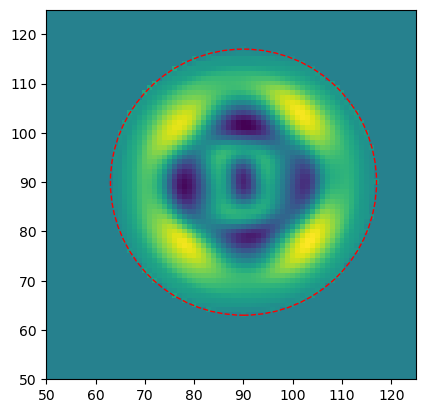

In [84]:
center = (90,90)
radius = 27

idx = mf.filter_zernike_modes(coeffs, sig_lim=1, angular_orders=[0,2,3,4], abs_indexes=False)

coeffs_ = np.zeros_like(coeffs)
coeffs_[idx] = coeffs[idx]
recon = np.sum(coeffs_[:, None, None]*modes, axis=0)

plt.imshow(recon)
patch = plt.Circle(center, radius, ls='--', color='r', fill=False)
plt.gca().add_patch(patch)
plt.xlim(50, 125)
plt.ylim(50, 125)
plt.show()

### Zernike Orientations

We can calculate the angle at which the poles are located from the zernike modes. Given the approximate nature of the representation of residual maps, instead of choosing to calculate the angle from a fixed (n,m), (n,-m) pair we can instead use all pairs (that are relevant) and average them while also weighing their contribution by their relative contribution to the reconstruction. This means the angle of a given $|m|$ mode is calculated as:
$$
\begin{align}
\phi_m &\approx\frac{1}{m}\arctan2(\Im{(A_m)}, \Re{(A_m)})\\
      A_m&=\sum^{}_{n}w^m_n(a^m_n+i\space a^{-m}_{n})\\
      w^m_n &= \sqrt{(a^m_n)^2+(a^{-m}_n)^2}
\end{align}
$$

Due to symmetries, we wrap the result of the angle to the domain $[0, \space \frac{\pi}{|m|})$ If the result of this domain wrapping is called $\phi_m'$, then the poles of the $|m|$ modes are located at angles:
$$
\phi'_m + n\frac{\pi}{|m|}, n=0,1,...,|m|-1
$$

We then represent the angle of each $|m|$ mode as its smallest angle representation taking $n=0$ in the previous formula.

1.684891979483103
41.67434680368275
31.907617808117806


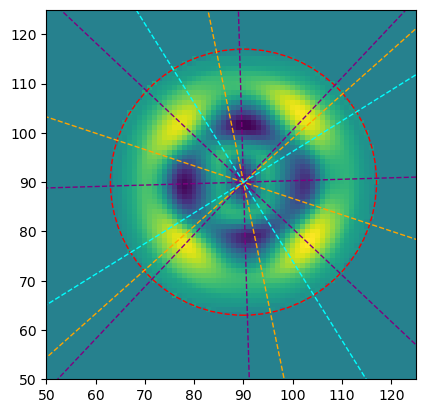

In [108]:
plt.imshow(recon)
patch = plt.Circle(center, radius, ls='--', color='r', fill=False)
plt.gca().add_patch(patch)
plt.xlim(50, 125)
plt.ylim(50, 125)

m=4
angle = mf.get_m_angle(coeffs_, m, nmax=31)
x0, y0 = 90, 90
L = 200 

pole_angles = angle + np.arange(m) * (np.pi / m)
print(np.rad2deg(angle))
for x in pole_angles:
    x1 = x0 - L * np.cos(x)
    y1 = y0 - L * np.sin(x)
    x2 = x0 + L * np.cos(x)
    y2 = y0 + L * np.sin(x)
    plt.plot([x1, x2], [y1, y2],
               linestyle='--', color='purple', linewidth=1)

m=3
angle = mf.get_m_angle(coeffs_, m, nmax=31)
x0, y0 = 90, 90
L = 200 

pole_angles = angle + np.arange(m) * (np.pi / m)
print(np.rad2deg(angle))
for x in pole_angles:
    x1 = x0 - L * np.cos(x)
    y1 = y0 - L * np.sin(x)
    x2 = x0 + L * np.cos(x)
    y2 = y0 + L * np.sin(x)
    plt.plot([x1, x2], [y1, y2],
               linestyle='--', color='orange', linewidth=1)

m=2
angle = mf.get_m_angle(coeffs_, m, nmax=31)
x0, y0 = 90, 90
L = 200 

pole_angles = angle + np.arange(m) * (np.pi / m)
print(np.rad2deg(angle))
for x in pole_angles:
    x1 = x0 - L * np.cos(x)
    y1 = y0 - L * np.sin(x)
    x2 = x0 + L * np.cos(x)
    y2 = y0 + L * np.sin(x)
    plt.plot([x1, x2], [y1, y2],
               linestyle='--', color='cyan', linewidth=1)
plt.show()